In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import tangram as tg
import muon as mu
import anndata as ad

import os
import sys
from pathlib import Path

%load_ext autoreload
%autoreload 2
%matplotlib inline

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

In [2]:
# Add the src directory to the path if it's not already there
notebook_dir = Path(os.getcwd())
if notebook_dir.name == 'src':
    sys.path.append(".")  # Add current directory
else:
    sys.path.append(str(notebook_dir / "src"))  # Add src directory

from config import H5AD_DIR, get_h5ad_path
from genomic_annotation import load_gencode_gtf_genes
print("success")

success


In [3]:
# read ad objects

ad_sp = sc.read_h5ad(get_h5ad_path("c_sp_ad.h5ad"))

ad_rna = sc.read_h5ad(get_h5ad_path("c_sc_ad.h5ad"))

ad_atac_genes = sc.read_h5ad(get_h5ad_path("c_atac_genes_ad.h5ad"))

In [4]:
# Convert gene names to sets (case-insensitive comparison)
overlapping_genes = set(ad_rna.var_names.str.lower()) & set(ad_sp.var_names.str.lower())

In [5]:
tg.pp_adatas(ad_rna, ad_sp, genes=overlapping_genes)

INFO:root:235 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:235 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [6]:
#trained on sp filtered (9 cells)

'''
ad_map = tg.map_cells_to_space(ad_rna, ad_sp,
    mode="cells",
#     mode="clusters",
#     cluster_label='cell_subclass',  # .obs field w cell types
    density_prior='rna_count_based',
    num_epochs=500,
    # device="cuda:0",
    device='cpu',
)
'''

'\nad_map = tg.map_cells_to_space(ad_rna, ad_sp,\n    mode="cells",\n#     mode="clusters",\n#     cluster_label=\'cell_subclass\',  # .obs field w cell types\n    density_prior=\'rna_count_based\',\n    num_epochs=500,\n    # device="cuda:0",\n    device=\'cpu\',\n)\n'

In [7]:
#ad_map.write_h5ad(str(H5AD_DIR / "c_filtered_map_ad.h5ad"))

In [8]:
ad_map = sc.read_h5ad(get_h5ad_path("c_filtered_map_ad.h5ad"))

In [9]:
tg.project_cell_annotations(ad_map, ad_sp, annotation="celltype")
copy_annotation_list = list(pd.unique(ad_rna.obs['celltype']))

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


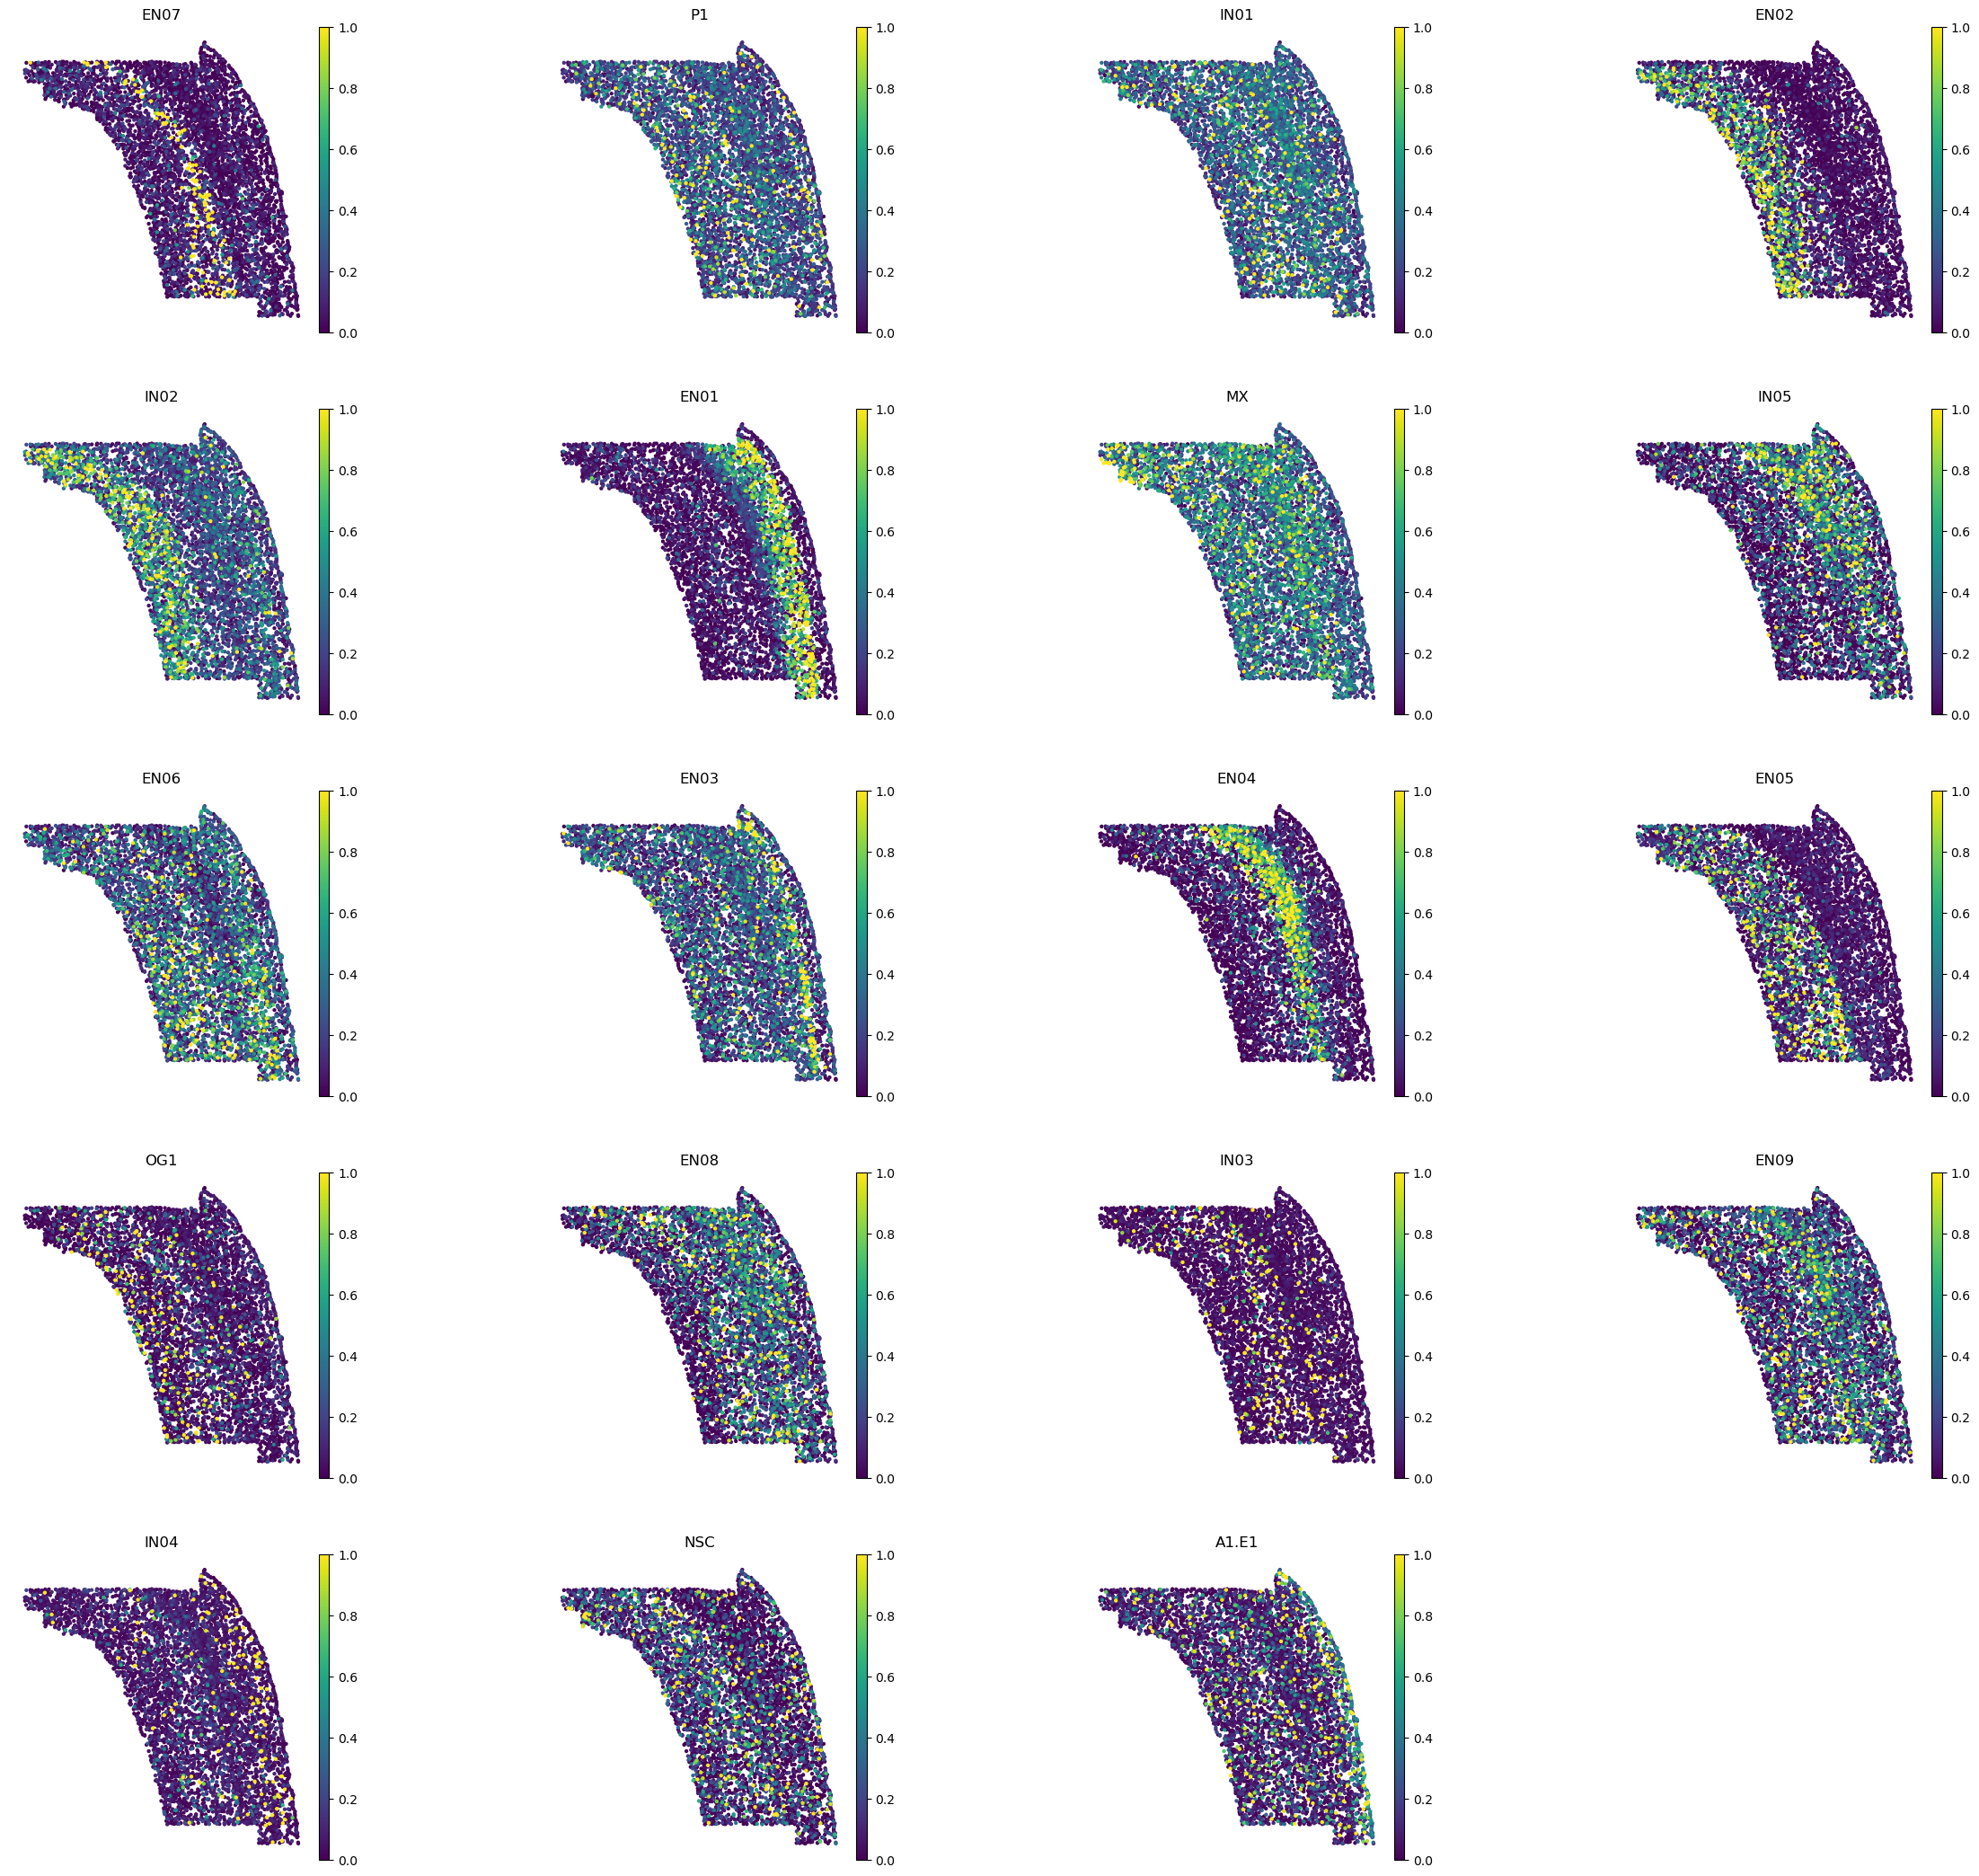

In [10]:
tg.plot_cell_annotation_sc(ad_sp, copy_annotation_list, spot_size=40, perc=0.02)

In [11]:
ad_sp_transcriptome = tg.project_genes(ad_map, ad_rna)

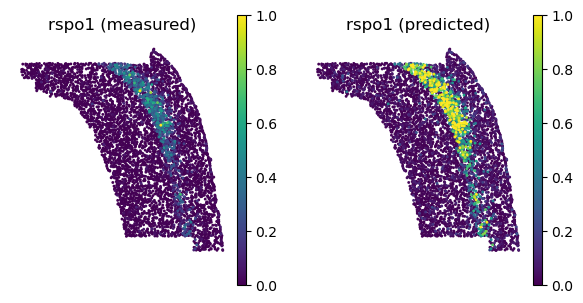

In [12]:
# IMPORTANT: this plotting methods adds "spatial" to ad_sp_transcriptome.obsm

tg.plot_genes_sc(genes=["rspo1"], adata_measured=ad_sp, adata_predicted=ad_sp_transcriptome, spot_size=40, perc=0.02,cmap="viridis")

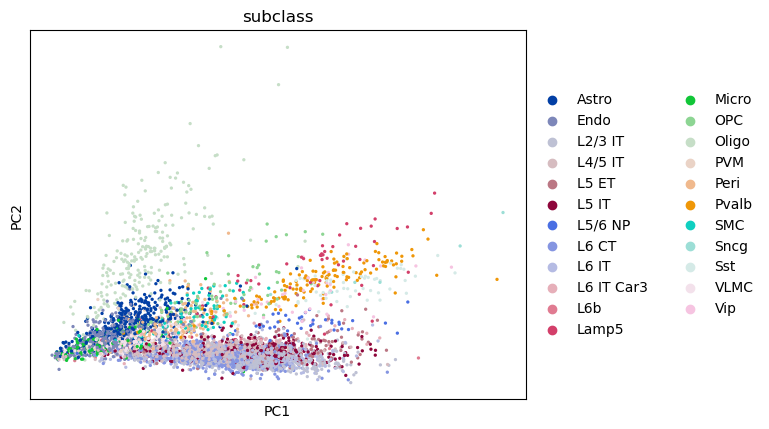

In [13]:
sc.tl.pca(ad_sp_transcriptome)

sc.pl.pca(
    ad_sp_transcriptome, color="subclass"
)

In [14]:
# nearest neighbor graph
sc.pp.neighbors(ad_sp_transcriptome, n_pcs=50)
nn_graph_genes = ad_sp_transcriptome.obsp["connectivities"]
# spatial proximity graph
sq.gr.spatial_neighbors(ad_sp_transcriptome)
nn_graph_space = ad_sp_transcriptome.obsp["spatial_connectivities"]

In [15]:
alpha = 0.2

joint_graph = (1 - alpha) * nn_graph_genes + alpha * nn_graph_space
sc.tl.leiden(ad_sp_transcriptome, adjacency=joint_graph, key_added="squidpy_domains")

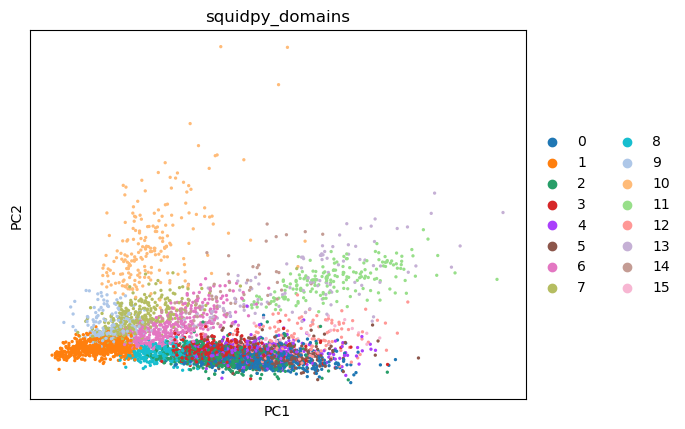

In [16]:
sc.pl.pca(
    ad_sp_transcriptome, color="squidpy_domains"
)

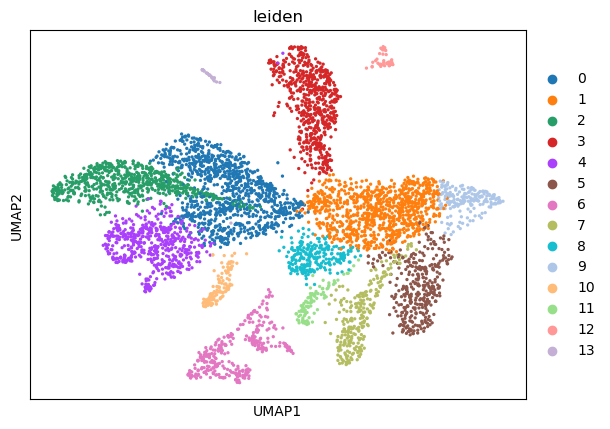

In [17]:
# Run Leiden clustering to identify spatial domains
sc.tl.leiden(ad_sp_transcriptome, resolution=0.5)

# UMAP visualization of the nichePCA embedding
sc.tl.umap(ad_sp_transcriptome)
sc.pl.umap(ad_sp_transcriptome, color="leiden")

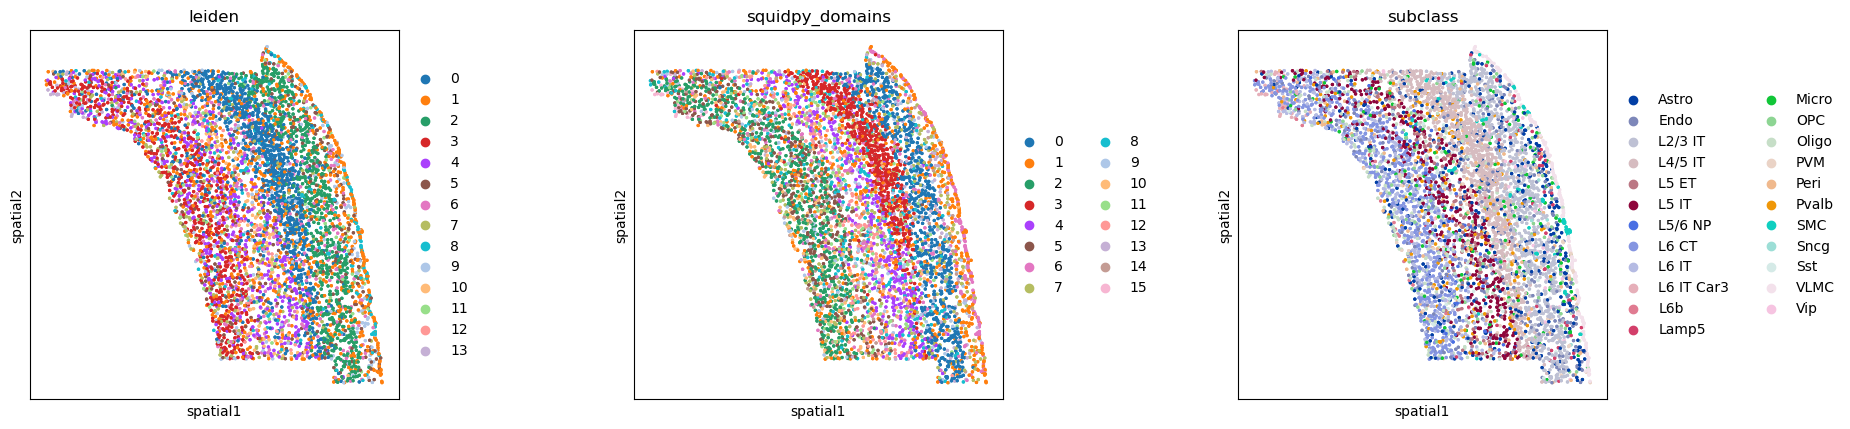

In [18]:
sq.pl.spatial_scatter(ad_sp_transcriptome, shape=None, color=["leiden", "squidpy_domains", "subclass"], size=8)

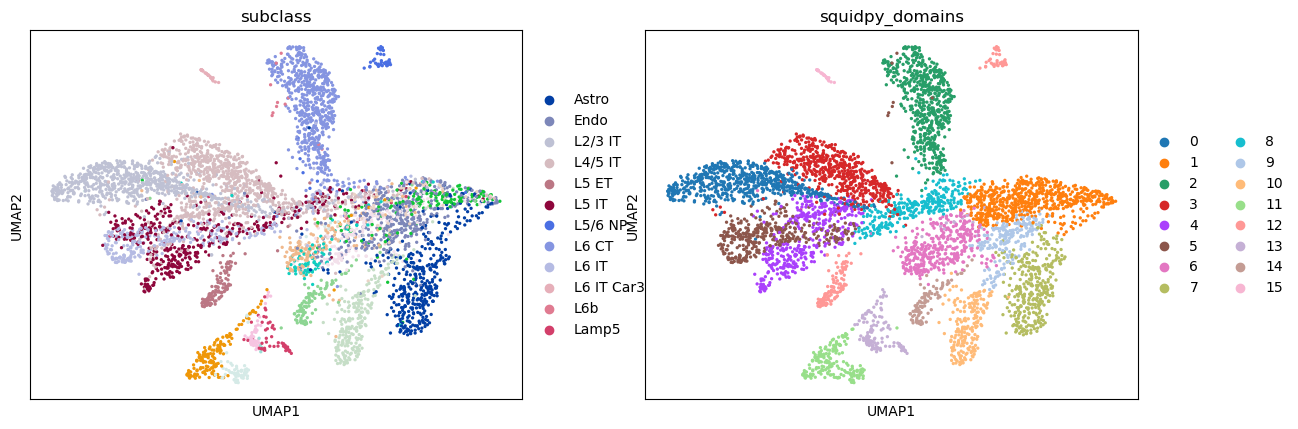

In [19]:
sc.pl.umap(ad_sp_transcriptome, color=["subclass", "squidpy_domains"])

## sp autoc on whole transcriptome spatial

In [20]:
sq.gr.spatial_neighbors(ad_sp_transcriptome)

In [21]:
sq.gr.spatial_autocorr(ad_sp_transcriptome, mode="geary")

In [22]:
geary_gene_names_list = ad_sp_transcriptome.uns["gearyC"].head(n=20).index.tolist()

In [3]:
sq.pl.spatial_scatter(
    ad_sp_transcriptome, shape=None, color=geary_gene_names_list, size=30
)

NameError: name 'ad_sp_transcriptome' is not defined

### annotating spatial transcriptome ad

In [ ]:
# Define the GTF URL
gtf_url = "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M10/gencode.vM10.annotation.gtf.gz"

# Load and process the genes, excluding chrY
try:
    gene_coords_gencode = load_gencode_gtf_genes(gtf_url, feature_type='gene', exclude_chroms=['chrY'])
except Exception as e:
    print(f"Failed to load or process GTF: {e}")

# Normalize to lowercase for matching
gene_coords_gencode.index = gene_coords_gencode.index.str.lower()

# Group by gene name and take the first row per group
gene_coords_unique = gene_coords_gencode.groupby(gene_coords_gencode.index).first()

# Find intersecting genes
shared_genes = ad_sp_transcriptome.var_names.intersection(gene_coords_unique.index)

# Extract and reindex
gene_metadata = gene_coords_unique.loc[shared_genes]

gene_metadata = gene_metadata.reindex(ad_sp_transcriptome.var_names)

# Add annotation
for col in ['chrom', 'start', 'end']:
    ad_sp_transcriptome.var[col] = gene_metadata[col]

In [71]:
#ad_sp_transcriptome.write(get_h5ad_path("c_sp_trans_wide_ad.h5ad"))

## ATAC

In [ ]:
'''
#maybe einfaach spatial übertragen

ad_atac_genes.obs_names = ad_map.obs_names

gene_accessibility_spatial = tg.project_genes(ad_map, ad_atac_genes)

gene_accessibility_spatial.obsm["spatial"] = np.array(gene_accessibility_spatial.obs[["centroid_x", "centroid_y"]])

gene_accessibility_spatial.write(get_h5ad_path("c_atac_spatial_ad.h5ad"))
'''

In [ ]:
gene_accessibility_spatial = sc.read_h5ad(get_h5ad_path("c_atac_spatial_ad.h5ad"))

## sp autocorr on atac

In [ ]:
sq.gr.spatial_neighbors(gene_accessibility_spatial)

In [ ]:
sq.gr.spatial_autocorr(gene_accessibility_spatial, mode="geary")

In [ ]:
geary_gene_names_list = gene_accessibility_spatial.uns["gearyC"].head(n=20).index.tolist()
print(geary_gene_names_list)

In [ ]:
sq.pl.spatial_scatter(
    gene_accessibility_spatial, shape=None, color=geary_gene_names_list, size=30
)

In [ ]:
sq.pl.spatial_scatter(
    gene_accessibility_spatial, shape=None, color="rorb", size=30
)

In [ ]:
sq.pl.spatial_scatter(
    gene_accessibility_spatial, shape=None, color="rspo1", size=30
)

In [ ]:
sq.gr.spatial_autocorr(gene_accessibility_spatial, mode="moran")

In [ ]:
moran_gene_names_list = gene_accessibility_spatial.uns["moranI"].head(n=20).index.tolist()

In [ ]:
# Convert the lists to sets
moran_genes_set = set(moran_gene_names_list)
geary_genes_set = set(geary_gene_names_list)

# Find the intersection using the intersection() method or the & operator
overlapping_genes = moran_genes_set.intersection(geary_genes_set)
# Or using the & operator:
# overlapping_genes = moran_genes_set & geary_genes_set

# Get the number of overlapping genes
num_overlapping_genes = len(overlapping_genes)

print(f"Number of genes overlapping in the top 20 for both measures: {num_overlapping_genes}")
print(f"Overlapping genes: {overlapping_genes}")

In [ ]:
# Genes in top 20 Moran that are NOT in top 20 Geary
unique_to_moran = moran_genes_set - geary_genes_set

# Genes in top 20 Geary that are NOT in top 20 Moran
unique_to_geary = geary_genes_set - moran_genes_set

print(f"Genes in top 20 Moran only: {unique_to_moran}")
print(f"Genes in top 20 Geary only: {unique_to_geary}")

## project peaks to space

rorb promoter:
19111117-19111464

<https://screen.wenglab.org/search?assembly=mm10&chromosome=chr19&start=18930605&end=19111196&gene=Rorb&tssDistance=0&nearTSS=f&dnase_s=-10&dnase_e=11&h3k4me3_s=-10&h3k4me3_e=11&h3k27ac_s=-10&h3k27ac_e=11&ctcf_s=-10&ctcf_e=11&atac_s=-10&atac_e=11&CA=t&CA_CTCF=t&CA_H3K4me3=t&CA_TF=t&dELS=t&pELS=t&PLS=t&TF=t&prim_s=-2&prim_e=2&mamm_s=-4&mamm_e=8&vert_s=-3&vert_e=8&linkedGeneName=&CTCFChIAPET=t_&RNAPIIChIAPET=t_&HiC=t_&CRISPRiFlowFISH=t_&eQTLs=t_&accessions=EM10E0673696&page=3>

In [ ]:
ad_atac = sc.read_h5ad(get_h5ad_path("c_atac_ad.h5ad"))

In [ ]:
ad_atac.obs_names = ad_map.obs_names

In [ ]:
ad_sp_peaks = tg.project_genes(ad_map, adata_sc=ad_atac)

In [ ]:
rorb_promoter_peaks = ad_sp_peaks.var[(ad_sp_peaks.var["start"]>19111117-1000)&(ad_sp_peaks.var["start"]<19111464+1000)]

In [ ]:
peak_list = rorb_promoter_peaks.index

In [ ]:
ad_sp_peaks.obsm["spatial"] = np.array(ad_sp_peaks.obs[["centroid_x", "centroid_y"]])

In [ ]:
sq.pl.spatial_scatter(
    ad_sp_peaks, shape=None, color=peak_list, size=30
)

In [ ]:
sq.gr.spatial_neighbors(ad_sp_peaks)

In [ ]:
sq.gr.spatial_autocorr(ad_sp_peaks, mode="geary")

In [ ]:
#ad_sp_peaks.write_h5ad(get_h5ad_path("atac_spatial_peaks.h5ad"))

In [ ]:
peak_geary_gene_names_list = ad_sp_peaks.uns["gearyC"].head(n=30).index.tolist()

In [ ]:
sq.pl.spatial_scatter(
    ad_sp_peaks, shape=None, color=peak_geary_gene_names_list, size=30
)

chr14:24249892-24250391

chr13:56030921-56031420

chr1 in mm10 from 135,901,626 to 135,902,125 -> Gm36938

In [ ]:
sq.pl.spatial_scatter(
    ad_sp_peaks, shape=None, color="chr4:141865001-141865500", size=17
)

In [ ]:
sq.pl.spatial_scatter(
    ad_sp_peaks, shape=None, color="chr19:18972253-18972752", size=12
)

In [ ]:
# Find index of the peak in .var_names
peak_name = "chr19:18972253-18972752"
#peak_name = "chr2:135970957-135971456"
#peak_name = "chr1:21275419-21275918"
#peak_name = "chr12:106734841-106735340"
peak_name = "chr10:68165220-68165719"
peak_name = "chr15:38907117-38907616"

peak_idx = list(ad_sp_peaks.var_names).index(peak_name)

# Extract values from .X (cells × peaks)
values = ad_sp_peaks.X[:, peak_idx]

# Get spatial coordinates
coords = ad_sp_peaks.obsm["spatial"]

# Plot as two layers: 0s in gray, values in color
import matplotlib.pyplot as plt
import numpy as np

is_zero = values < 0.001
is_nonzero = values > 0.001

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(coords[is_zero, 0], coords[is_zero, 1], c="lightgray", s=5, label="zero")
sc = ax.scatter(coords[is_nonzero, 0], coords[is_nonzero, 1], c=values[is_nonzero],
                cmap="viridis", s=5)
plt.colorbar(sc, ax=ax).set_label("Peak Accessibility")
ax.set_title(peak_name)
ax.set_xlabel("spatial1")
ax.set_ylabel("spatial2")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
sq.pl.spatial_scatter(
    ad_sp_peaks, shape=None, color="chr2:135970957-135971456", size=12
)